# YOLO XAI: Grad-CAM and Feature Maps

Use this notebook to inspect the YOLO model with Grad-CAM and intermediate feature maps.

Update `model_path` and `image_path` before running the code cells.

In [1]:
from pathlib import Path
import sys
from importlib import reload

import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.detection.yolo_layout import YoloLayoutDetector
import yolo_xai
reload(yolo_xai)
from yolo_xai import YOLOXAI

DATA_ROOT = Path(r"D:\DSE\DSE-Y3\S2\AI\Ai project ideas\AI\Two Classes")
model_path = DATA_ROOT / "best.pt"
image_path = DATA_ROOT / "test" / "images" / "IMG_8245_jpg.rf.3d6465317db204e026ba729fe24da144"

# If the provided image path is missing an extension, try common ones.
if not image_path.exists():
    candidates: list[Path] = []
    if image_path.suffix == "":
        for ext in (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"):
            candidates.append(image_path.with_suffix(ext))
    # Also try any file that matches the same base name.
    candidates.extend(sorted(image_path.parent.glob(image_path.name + ".*")))
    for cand in candidates:
        if cand.exists():
            image_path = cand
            break

print("Project root:", PROJECT_ROOT)
print("Model exists:", model_path.exists()) 
print("Image exists:", image_path.exists())
print("Image path:", image_path)

Project root: D:\DSE\DSE-Y3\S2\AI\Ai project ideas\AI
Model exists: True
Image exists: True
Image path: D:\DSE\DSE-Y3\S2\AI\Ai project ideas\AI\Two Classes\test\images\IMG_8245_jpg.rf.3d6465317db204e026ba729fe24da144.jpg


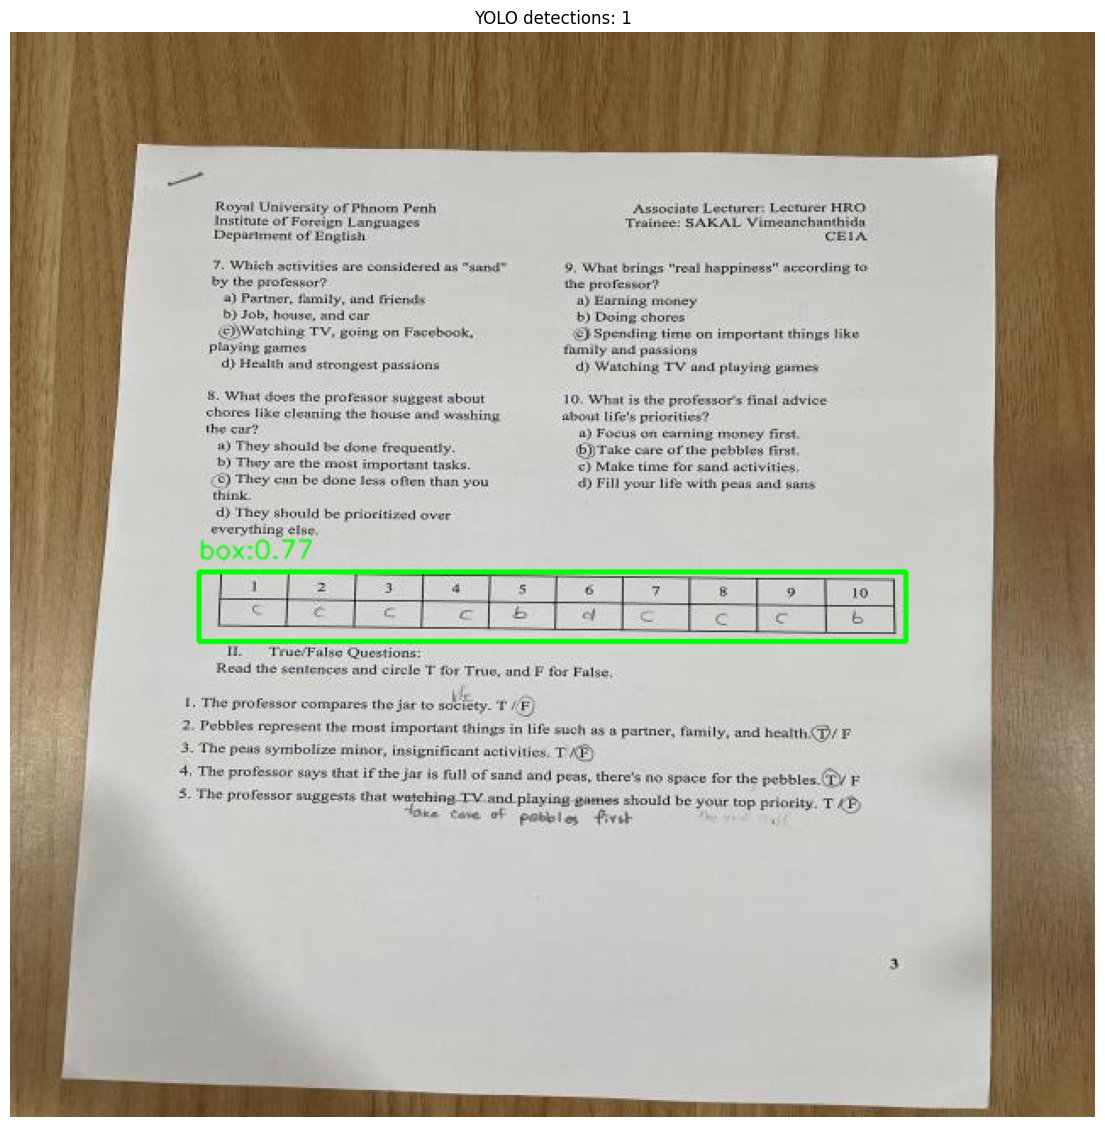

Selected detection: label=box conf=0.770 bbox=(111,318)-(528,359)


In [2]:
image = cv2.imread(str(image_path))
if image is None:
    raise ValueError(f"Could not read image: {image_path}")

detector = YoloLayoutDetector(str(model_path))
if detector.model is None:
    raise RuntimeError(
        "YOLO model is not loaded (ultralytics missing or model_path not found).\n"
        f"model_path={model_path}\n"
        "Fix: `pip install ultralytics` and verify the .pt path."
    )

detections = detector.detect(image)
selected_det = max(detections, key=lambda d: d.confidence) if detections else None

vis = image.copy()
for det in detections:
    cv2.rectangle(vis, (det.x1, det.y1), (det.x2, det.y2), (0, 255, 0), 2)
    cv2.putText(
        vis,
        f"{det.label}:{det.confidence:.2f}",
        (det.x1, max(20, det.y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(14, 18))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"YOLO detections: {len(detections)}")
plt.show()

if selected_det is None:
    print("No detections found; XAI will still run but isn't box-focused.")
else:
    print(
        "Selected detection:",
        f"label={selected_det.label}",
        f"conf={selected_det.confidence:.3f}",
        f"bbox=({selected_det.x1},{selected_det.y1})-({selected_det.x2},{selected_det.y2})",
    )

In [3]:
xai = YOLOXAI(detector.model)
xai_result = xai.generate(image)

print("XAI note:", xai_result.note)
print("Target layer:", xai_result.target_layer_name)
print("Feature maps:", len(xai_result.feature_maps))

if selected_det is not None:
    print("Top detection used for visualization:")
    print("  label:", selected_det.label)
    print("  confidence:", f"{selected_det.confidence:.3f}")
    print("  bbox:", (selected_det.x1, selected_det.y1, selected_det.x2, selected_det.y2))

XAI note: OK
Target layer: 21-C2f
Feature maps: 3
Top detection used for visualization:
  label: box
  confidence: 0.770
  bbox: (111, 318, 528, 359)


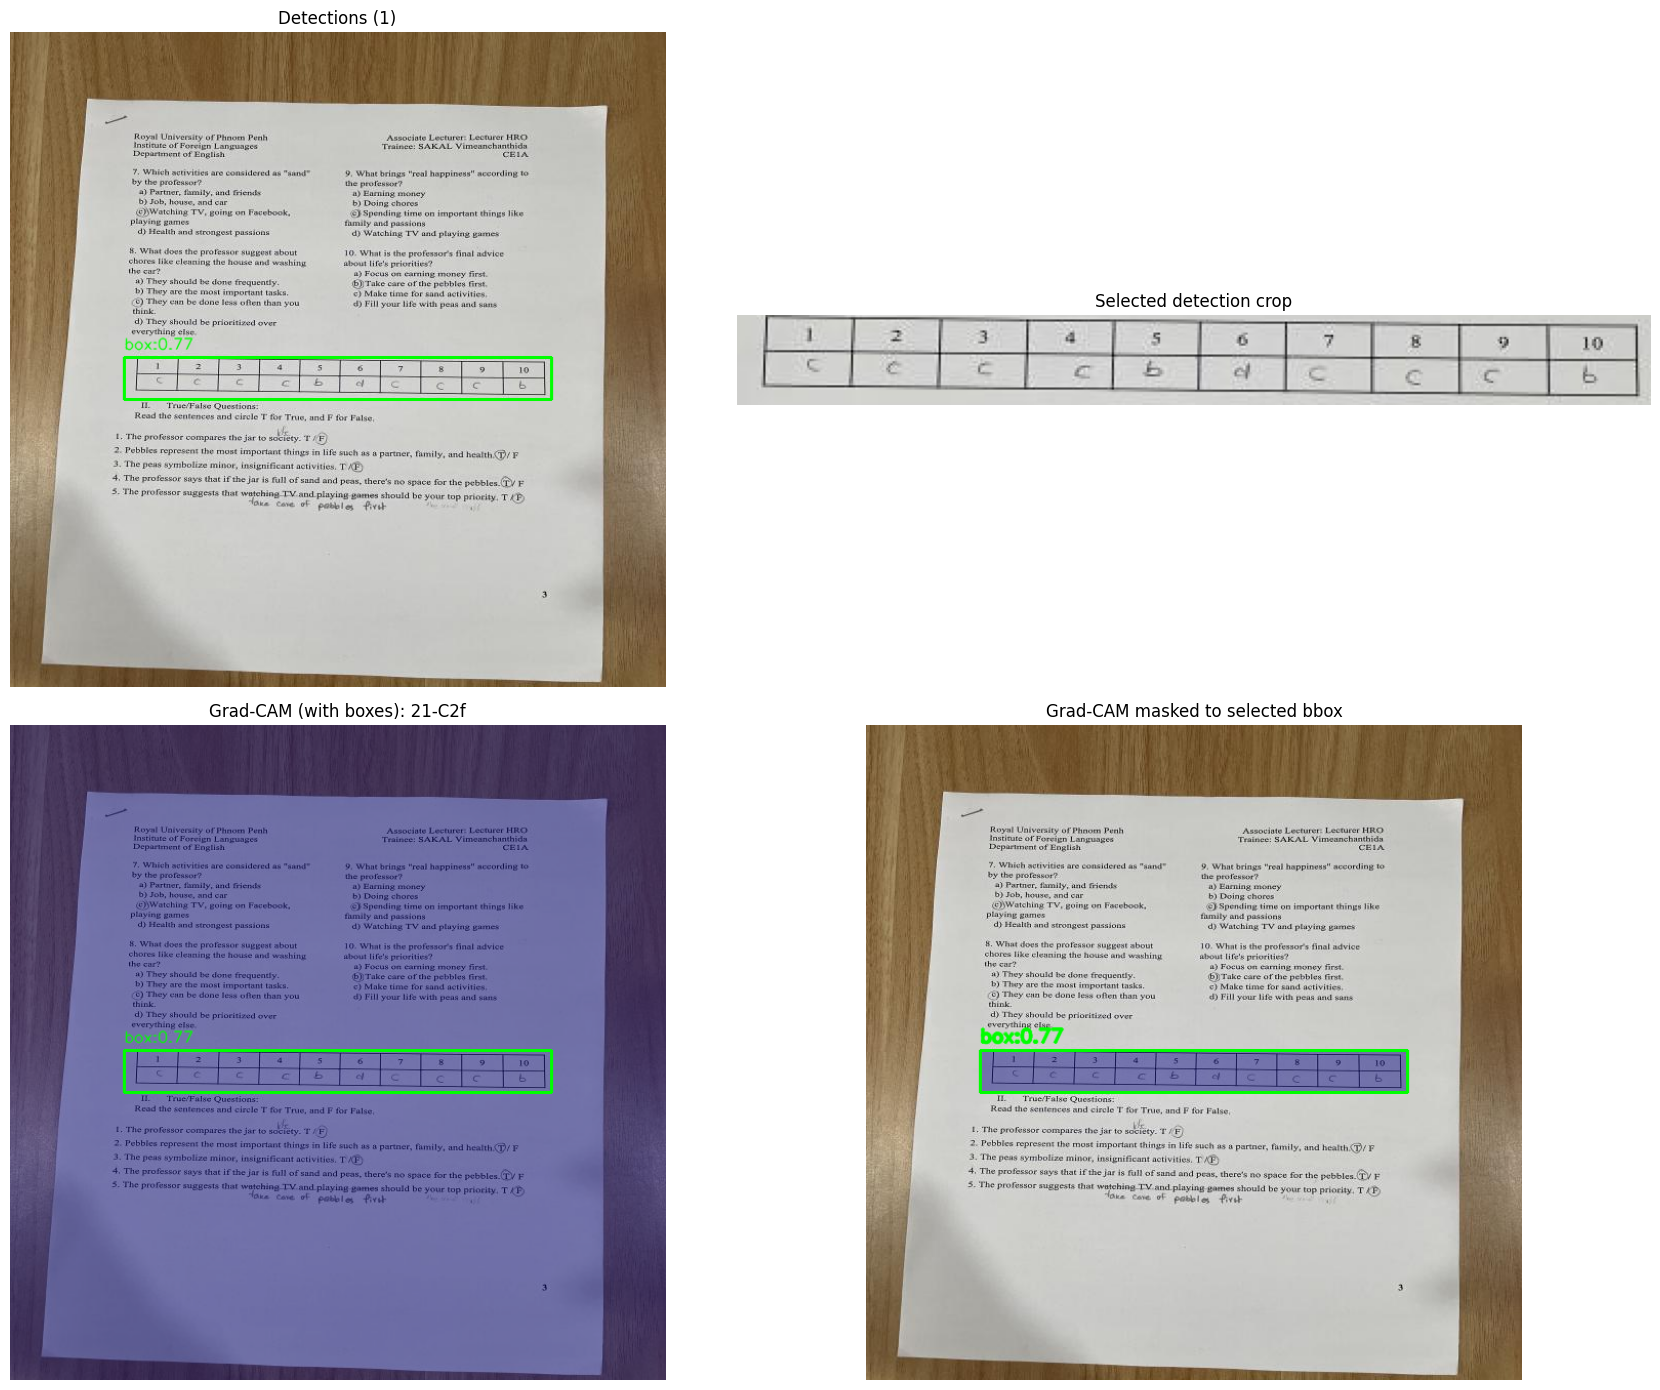

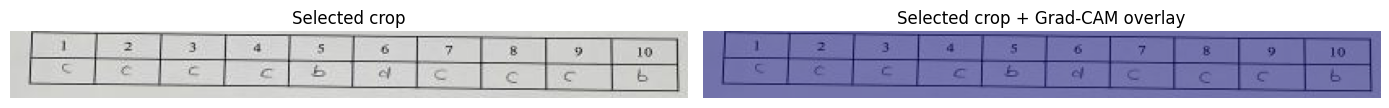


Explanation summary
- XAI status: OK
- Target layer: 21-C2f
- Selected detection: box (0.770)
- Feature maps captured: 3


In [4]:
def _clamp_bbox(x1: int, y1: int, x2: int, y2: int, w: int, h: int) -> tuple[int, int, int, int]:
    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(0, min(int(x2), w))
    y2 = max(0, min(int(y2), h))
    if x2 <= x1:
        x2 = min(w, x1 + 1)
    if y2 <= y1:
        y2 = min(h, y1 + 1)
    return x1, y1, x2, y2

h, w = image.shape[:2]
selected_crop = None
gradcam_with_boxes = None
gradcam_masked = None
selected_gradcam_crop = None

if xai_result.gradcam_overlay is not None:
    gradcam_with_boxes = xai_result.gradcam_overlay.copy()
    # Overlay all detection boxes on Grad-CAM for context
    for det in detections:
        cv2.rectangle(gradcam_with_boxes, (det.x1, det.y1), (det.x2, det.y2), (0, 255, 0), 2)
        cv2.putText(
            gradcam_with_boxes,
            f"{det.label}:{det.confidence:.2f}",
            (det.x1, max(20, det.y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )

    if selected_det is not None:
        x1, y1, x2, y2 = _clamp_bbox(selected_det.x1, selected_det.y1, selected_det.x2, selected_det.y2, w=w, h=h)
        selected_crop = image[y1:y2, x1:x2].copy()
        selected_gradcam_crop = xai_result.gradcam_overlay[y1:y2, x1:x2].copy()
        gradcam_masked = image.copy()
        # Show heatmap only inside the selected detection bbox (simple, reliable 'box-aware' visualization).
        gradcam_masked[y1:y2, x1:x2] = xai_result.gradcam_overlay[y1:y2, x1:x2]
        cv2.rectangle(gradcam_masked, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            gradcam_masked,
            f"{selected_det.label}:{selected_det.confidence:.2f}",
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Detections ({len(detections)})")
axes[0].axis('off')

if selected_crop is not None:
    axes[1].imshow(cv2.cvtColor(selected_crop, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Selected detection crop")
else:
    axes[1].text(0.5, 0.5, "No selected detection", ha='center', va='center')
    axes[1].set_title("Selected detection crop")
axes[1].axis('off')

if gradcam_with_boxes is not None:
    axes[2].imshow(cv2.cvtColor(gradcam_with_boxes, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Grad-CAM (with boxes): {xai_result.target_layer_name}")
else:
    axes[2].text(0.5, 0.5, "Grad-CAM unavailable", ha='center', va='center')
    axes[2].set_title("Grad-CAM")
axes[2].axis('off')

if gradcam_masked is not None:
    axes[3].imshow(cv2.cvtColor(gradcam_masked, cv2.COLOR_BGR2RGB))
    axes[3].set_title("Grad-CAM masked to selected bbox")
else:
    axes[3].text(0.5, 0.5, "Masked Grad-CAM unavailable", ha='center', va='center')
    axes[3].set_title("Masked Grad-CAM")
axes[3].axis('off')

plt.tight_layout()
plt.show()

if selected_gradcam_crop is not None and selected_crop is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(selected_crop, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Selected crop")
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(selected_gradcam_crop, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Selected crop + Grad-CAM overlay")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

print("\nExplanation summary")
print("- XAI status:", xai_result.note)
print("- Target layer:", xai_result.target_layer_name)
if selected_det is not None:
    print("- Selected detection:", f"{selected_det.label} ({selected_det.confidence:.3f})")
else:
    print("- Selected detection: None")
print("- Feature maps captured:", len(xai_result.feature_maps))

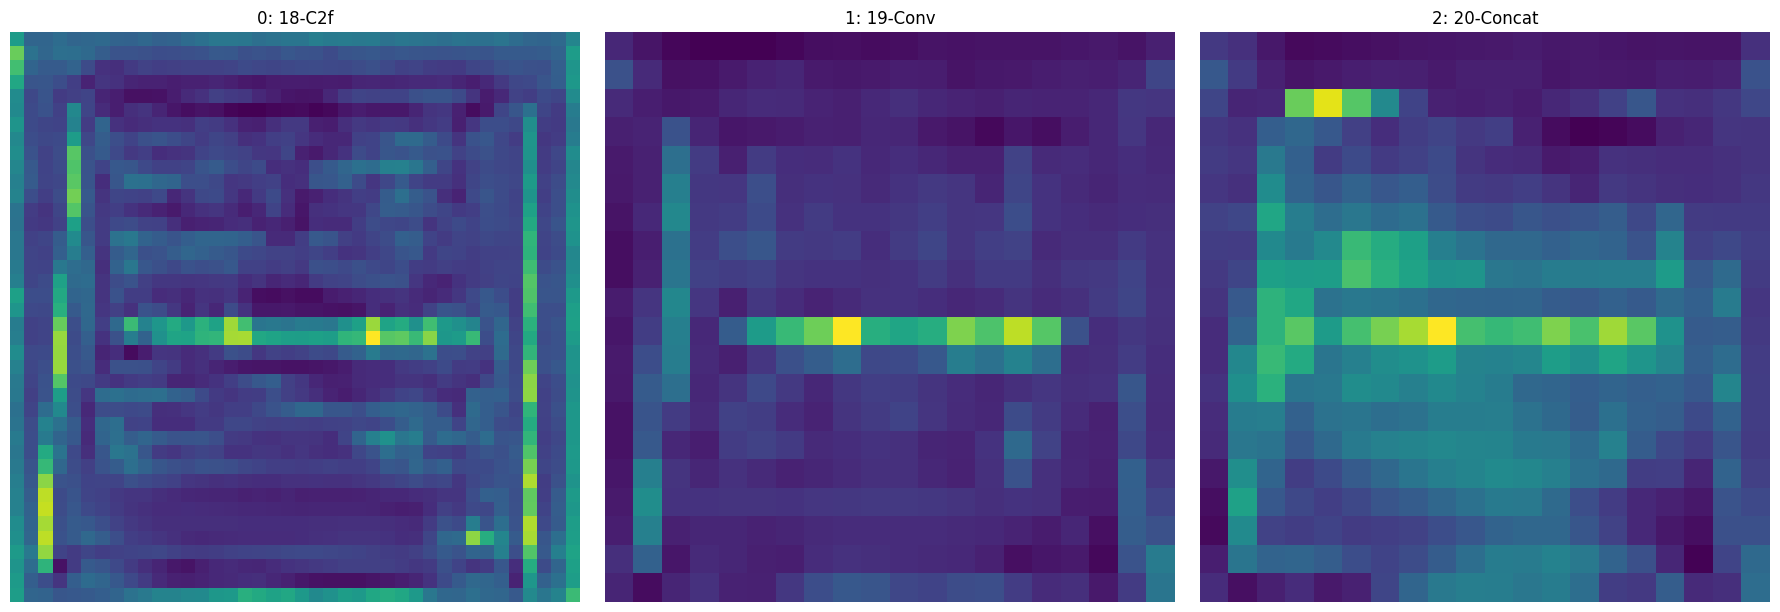

In [5]:
if xai_result.feature_maps:
    cols = 3
    rows = (len(xai_result.feature_maps) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for idx, (layer_name, fmap) in enumerate(xai_result.feature_maps):
        axes[idx].imshow(fmap, cmap='viridis')
        axes[idx].set_title(f"{idx}: {layer_name}")
        axes[idx].axis('off')

    for idx in range(len(xai_result.feature_maps), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No feature maps were captured.')